# CS506 Midterm — Amazon Review Rating Prediction
Ridge Regression + user/product bias features + TF-IDF

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path('..').resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from src.data import load_train_data, load_test_data
from src.features import prepare_training_data, prepare_test_data
from src.model import train_ridge, evaluate_model, save_model, create_submission

## 1. Load data
The test IDs are embedded in train.csv with NaN scores — we extract them here.

In [2]:
raw = load_train_data('../data/train.csv')
test_ids_df = load_test_data('../data/test.csv')

# Split labeled vs unlabeled
labeled   = raw.dropna(subset=['Score']).copy()
test_df   = raw[raw['Id'].isin(test_ids_df['Id'])].copy()

print('Labeled rows :', len(labeled))
print('Test rows    :', len(test_df))
print('Score distribution:')
print(labeled['Score'].value_counts().sort_index())

Labeled rows : 125777
Test rows    : 13976
Score distribution:
Score
1.0     7593
2.0     7567
3.0    14857
4.0    28572
5.0    67188
Name: count, dtype: int64


## 2. Honest validation — split first, fit on train fold only

To avoid data leakage, we split the labeled DataFrame **before** fitting any transformers.
Bias features and TF-IDF are fit on the train fold only, then applied to the validation fold.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import text as sk_text
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from scipy.sparse import hstack, csr_matrix
import pandas as pd
import numpy as np
from src.features import build_bias_features, build_bias_features_loo, build_baseline, build_numeric_features, build_sentiment_features

labeled = raw.dropna(subset=['Score']).copy()

# Split FIRST — no leakage
train_df, valid_df = train_test_split(labeled, test_size=0.2, random_state=42, stratify=labeled['Score'])
print('Train fold:', len(train_df), '  Valid fold:', len(valid_df))

# --- Bias baseline (two-stage) ---
baseline_tr = build_baseline(train_df, train_df)
baseline_va = build_baseline(train_df, valid_df)
y_train_raw = train_df['Score'].values
y_valid     = valid_df['Score'].values
y_train     = y_train_raw - baseline_tr   # residuals for Ridge

# --- Stopwords ---
movie_stop = {"movie","film","watch","watched","one","really","also","even","get","got","make","made"}
stop_words = list(sk_text.ENGLISH_STOP_WORDS.union(movie_stop))
base_kwargs = dict(lowercase=True, stop_words=stop_words, ngram_range=(1,2),
                   min_df=2, max_df=0.9, sublinear_tf=True, norm='l2',
                   smooth_idf=True, use_idf=True)

# --- Separate TF-IDF: Summary (10k) and Text (30k) + char n-grams (20k) ---
tfidf_summary_val = TfidfVectorizer(max_features=10000, **base_kwargs)
tfidf_text_val    = TfidfVectorizer(max_features=30000, **base_kwargs)
tfidf_char_val    = TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5),
    min_df=5, max_df=0.9, sublinear_tf=True, norm='l2', max_features=20000, lowercase=True)

X_sum_tr = tfidf_summary_val.fit_transform(train_df['Summary'].fillna('').astype(str))
X_sum_va = tfidf_summary_val.transform(valid_df['Summary'].fillna('').astype(str))
X_txt_tr = tfidf_text_val.fit_transform(train_df['Text'].fillna('').astype(str))
X_txt_va = tfidf_text_val.transform(valid_df['Text'].fillna('').astype(str))
X_chr_tr = tfidf_char_val.fit_transform(train_df['Text'].fillna('').astype(str))
X_chr_va = tfidf_char_val.transform(valid_df['Text'].fillna('').astype(str))

X_text_tr = hstack([X_sum_tr, X_txt_tr, X_chr_tr])
X_text_va = hstack([X_sum_va, X_txt_va, X_chr_va])

# --- SVD ---
svd_val = TruncatedSVD(n_components=200, random_state=42)
X_lsa_tr = Normalizer().fit_transform(svd_val.fit_transform(X_text_tr))
X_lsa_va = Normalizer().fit_transform(svd_val.transform(X_text_va))

# --- Numeric + sentiment (no bias in X — bias is in baseline) ---
num_tr_raw = build_numeric_features(train_df)
sent_tr    = build_sentiment_features(train_df)
num_tr_df  = pd.concat([num_tr_raw, sent_tr], axis=1)
num_cols   = num_tr_df.columns.tolist()

num_va_raw = build_numeric_features(valid_df)
sent_va    = build_sentiment_features(valid_df)
num_va_df  = pd.concat([num_va_raw, sent_va], axis=1).reindex(columns=num_cols, fill_value=0).fillna(0)

# --- Also compute bias for LightGBM (kept as features, LOO version for training) ---
bias_tr = build_bias_features(train_df, train_df)
bias_va = build_bias_features(train_df, valid_df)

X_train = hstack([csr_matrix(num_tr_df.values), X_text_tr, csr_matrix(X_lsa_tr)])
X_valid = hstack([csr_matrix(num_va_df.values), X_text_va, csr_matrix(X_lsa_va)])

print('X_train:', X_train.shape, '  X_valid:', X_valid.shape)
print('Baseline train RMSE (bias only):', round(float(np.sqrt(np.mean((y_train_raw - baseline_tr)**2))), 4))


Train fold: 100621   Valid fold: 25156
X_train: (100621, 60220)   X_valid: (25156, 60220)
Baseline train RMSE (bias only): 0.9592


## 4. Models: Ridge Regression + LightGBM

Ridge on all sparse features (TF-IDF + LSA + bias + numeric + sentiment).  
LightGBM on **dense features only** (LSA + bias + numeric + sentiment) — trees can't exploit sparse TF-IDF efficiently.


In [4]:
from sklearn.metrics import mean_squared_error
best_rmse = 999
best_alpha = None
results = []

for alpha in [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0]:
    model = train_ridge(X_train, y_train, alpha=alpha)   # y_train = residuals
    resid_pred_va = model.predict(X_valid)
    final_va = np.clip(baseline_va + resid_pred_va, 1, 5)
    rmse = np.sqrt(mean_squared_error(y_valid, final_va))
    results.append((alpha, rmse))
    print(f'Ridge alpha={alpha}  valid RMSE: {rmse:.4f}')
    if rmse < best_rmse:
        best_rmse = rmse
        best_alpha = alpha

print(f'\nBest alpha: {best_alpha}  |  Best valid RMSE: {best_rmse:.4f}')


Ridge alpha=0.01  valid RMSE: 0.7809
Ridge alpha=0.05  valid RMSE: 0.7702
Ridge alpha=0.1  valid RMSE: 0.7713
Ridge alpha=0.5  valid RMSE: 0.7675
Ridge alpha=1.0  valid RMSE: 0.7652
Ridge alpha=5.0  valid RMSE: 0.7598
Ridge alpha=10.0  valid RMSE: 0.7624
Ridge alpha=50.0  valid RMSE: 0.7835

Best alpha: 5.0  |  Best valid RMSE: 0.7598


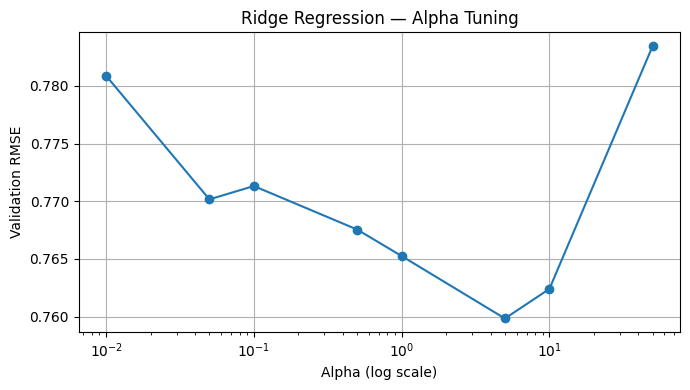

In [5]:
alphas, rmses = zip(*results)
plt.figure(figsize=(7, 4))
plt.semilogx(alphas, rmses, marker='o')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Validation RMSE')
plt.title('Ridge Regression — Alpha Tuning')
plt.grid(True)
plt.tight_layout()
plt.savefig('../assets/ridge_alpha_tuning.png', dpi=100)
plt.show()

In [6]:
## Experiment: two-stage residual prediction
# Stage 1: bias-only baseline = global_mean + smoothed user_bias + smoothed product_bias
# Stage 2: Ridge trained on residual (score - baseline) using text + numeric + sentiment
# Final:   prediction = baseline + residual_pred, clipped to [1,5]

import numpy as np
from scipy.sparse import hstack, csr_matrix
from sklearn.preprocessing import Normalizer
from src.model import train_ridge
from sklearn.metrics import mean_squared_error

# --- Stage 1: compute bias baseline on train fold ---
global_mean = y_train.mean()

# Reuse bias_tr and bias_va (already computed from train fold — no leakage)
# bias columns: [user_mean, user_count, user_std, product_mean, product_count, product_std,
#                user_bias, product_bias, user_product_bias]
user_bias_tr  = bias_tr[:, 6]   # user_bias column
prod_bias_tr  = bias_tr[:, 7]   # product_bias column
user_bias_va  = bias_va[:, 6]
prod_bias_va  = bias_va[:, 7]

baseline_tr = np.clip(global_mean + user_bias_tr + prod_bias_tr, 1, 5)
baseline_va = np.clip(global_mean + user_bias_va + prod_bias_va, 1, 5)

residual_tr = y_train - baseline_tr

print(f"Global mean         : {global_mean:.4f}")
print(f"Baseline train RMSE : {np.sqrt(mean_squared_error(y_train, baseline_tr)):.4f}")
print(f"Baseline valid RMSE : {np.sqrt(mean_squared_error(y_valid, baseline_va)):.4f}")
print(f"Residual std        : {residual_tr.std():.4f}  (target variance after bias removal)")

# --- Stage 2: Ridge on text + numeric + sentiment (no bias cols) to predict residual ---
# Use X_text_tr/va and LSA already computed — just drop the bias block
# X_train layout: [numeric | bias | text | lsa]
# numeric cols = num_tr_df.shape[1], bias cols = 9
n_num  = num_tr_df.shape[1]
n_bias = 9

# Build feature matrix without bias columns (bias is already captured in baseline)
X_text_only_tr = hstack([
    csr_matrix(num_tr_df.values),
    X_text_tr,
    csr_matrix(X_lsa_tr)
])
X_text_only_va = hstack([
    csr_matrix(num_va_df.values),
    X_text_va,
    csr_matrix(X_lsa_va)
])

# Train on residuals
residual_model = train_ridge(X_text_only_tr, residual_tr, alpha=best_alpha)

resid_pred_tr = residual_model.predict(X_text_only_tr)
resid_pred_va = residual_model.predict(X_text_only_va)

final_tr = np.clip(baseline_tr + resid_pred_tr, 1, 5)
final_va = np.clip(baseline_va + resid_pred_va, 1, 5)

two_stage_train_rmse = np.sqrt(mean_squared_error(y_train, final_tr))
two_stage_valid_rmse = np.sqrt(mean_squared_error(y_valid, final_va))

print(f"\n--- Results ---")
print(f"Current Ridge (all-in-one)  valid RMSE : {best_rmse:.4f}")
print(f"Two-stage residual          valid RMSE : {two_stage_valid_rmse:.4f}")
print(f"Train RMSE                             : {two_stage_train_rmse:.4f}")
print(f"Improvement                            : {best_rmse - two_stage_valid_rmse:+.4f}")


Global mean         : 0.0210
Baseline train RMSE : 1.3704
Baseline valid RMSE : 3.3352
Residual std        : 0.9590  (target variance after bias removal)

--- Results ---
Current Ridge (all-in-one)  valid RMSE : 0.7598
Two-stage residual          valid RMSE : 3.3328
Train RMSE                             : 1.3708
Improvement                            : -2.5730


In [7]:
## Experiment: separate Summary+Text TF-IDF vs concatenated
# Current approach: separate vectorizers (10k summary, 30k text)
# Alternative: single vectorizer on "summary + text" string (40k features)
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import text as sk_text
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from scipy.sparse import hstack, csr_matrix
from src.model import train_ridge
from sklearn.metrics import mean_squared_error

movie_stop = {"movie","film","watch","watched","one","really","also","even","get","got","make","made"}
stop_words = list(sk_text.ENGLISH_STOP_WORDS.union(movie_stop))
base_kw = dict(min_df=2, max_df=0.9, ngram_range=(1,2), sublinear_tf=True,
               norm="l2", smooth_idf=True, use_idf=True, lowercase=True,
               stop_words=stop_words)

X_fixed_tr = hstack([csr_matrix(num_tr_df.values), csr_matrix(bias_tr)])
X_fixed_va = hstack([csr_matrix(num_va_df.values), csr_matrix(bias_va)])

# Shared char n-grams
tfidf_char_exp = TfidfVectorizer(analyzer="char_wb", ngram_range=(3,5),
    min_df=5, max_df=0.9, sublinear_tf=True, norm="l2", max_features=20000, lowercase=True)
X_chr_tr = tfidf_char_exp.fit_transform(train_df["Text"].fillna("").astype(str))
X_chr_va = tfidf_char_exp.transform(valid_df["Text"].fillna("").astype(str))

def eval_text_features(X_text_tr, X_text_va, label):
    svd_e = TruncatedSVD(n_components=200, random_state=42)
    X_lsa_tr_e = Normalizer().fit_transform(svd_e.fit_transform(X_text_tr))
    X_lsa_va_e = Normalizer().fit_transform(svd_e.transform(X_text_va))
    X_tr = hstack([X_fixed_tr, X_text_tr, csr_matrix(X_lsa_tr_e)])
    X_va = hstack([X_fixed_va, X_text_va, csr_matrix(X_lsa_va_e)])
    m = train_ridge(X_tr, y_train, alpha=best_alpha)
    rmse = np.sqrt(mean_squared_error(y_valid, np.clip(m.predict(X_va), 1, 5)))
    print(f"  {label:<45} RMSE: {rmse:.4f}")
    return rmse

print("Separate vs concatenated TF-IDF:")

# Option A: separate (current)
tv_sum = TfidfVectorizer(max_features=10000, **base_kw)
tv_txt = TfidfVectorizer(max_features=30000, **base_kw)
X_A_tr = hstack([tv_sum.fit_transform(train_df["Summary"].fillna("").astype(str)),
                 tv_txt.fit_transform(train_df["Text"].fillna("").astype(str)), X_chr_tr])
X_A_va = hstack([tv_sum.transform(valid_df["Summary"].fillna("").astype(str)),
                 tv_txt.transform(valid_df["Text"].fillna("").astype(str)), X_chr_va])
eval_text_features(X_A_tr, X_A_va, "Separate (10k summary + 30k text) [current]")

# Option B: concatenated summary+text, single vectorizer
tv_concat = TfidfVectorizer(max_features=40000, **base_kw)
combined_tr = train_df["Summary"].fillna("").astype(str) + " " + train_df["Text"].fillna("").astype(str)
combined_va = valid_df["Summary"].fillna("").astype(str) + " " + valid_df["Text"].fillna("").astype(str)
X_B_tr = hstack([tv_concat.fit_transform(combined_tr), X_chr_tr])
X_B_va = hstack([tv_concat.transform(combined_va), X_chr_va])
eval_text_features(X_B_tr, X_B_va, "Concatenated (40k combined summary+text)")

# Option C: separate with higher summary weight (repeat summary twice)
combined_tr2 = train_df["Summary"].fillna("").astype(str) + " " + train_df["Summary"].fillna("").astype(str) + " " + train_df["Text"].fillna("").astype(str)
combined_va2 = valid_df["Summary"].fillna("").astype(str) + " " + valid_df["Summary"].fillna("").astype(str) + " " + valid_df["Text"].fillna("").astype(str)
tv_concat2 = TfidfVectorizer(max_features=40000, **base_kw)
X_C_tr = hstack([tv_concat2.fit_transform(combined_tr2), X_chr_tr])
X_C_va = hstack([tv_concat2.transform(combined_va2), X_chr_va])
eval_text_features(X_C_tr, X_C_va, "Concatenated with summary repeated 2x (boost)")


Separate vs concatenated TF-IDF:
  Separate (10k summary + 30k text) [current]   RMSE: 3.3332
  Concatenated (40k combined summary+text)      RMSE: 3.3334
  Concatenated with summary repeated 2x (boost) RMSE: 3.3334


np.float64(3.333394398024962)

In [8]:
## Experiment: stemming and lemmatization
# Tests whether normalizing word forms (running→run, better→good) helps RMSE.
# Using a custom tokenizer inside TfidfVectorizer — no preprocessing overhead outside.
import ssl, nltk
try:
    ssl._create_default_https_context = ssl._create_unverified_context
except AttributeError:
    pass
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

import re
import numpy as np
from nltk.stem import PorterStemmer, WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import text as sk_text
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from scipy.sparse import hstack, csr_matrix
from src.model import train_ridge
from sklearn.metrics import mean_squared_error

movie_stop = {"movie","film","watch","watched","one","really","also","even","get","got","make","made"}
stop_words = list(sk_text.ENGLISH_STOP_WORDS.union(movie_stop))
base_kw = dict(min_df=2, max_df=0.9, ngram_range=(1,2), sublinear_tf=True,
               norm="l2", smooth_idf=True, use_idf=True, lowercase=True,
               stop_words=stop_words)

X_fixed_tr = hstack([csr_matrix(num_tr_df.values), csr_matrix(bias_tr)])
X_fixed_va = hstack([csr_matrix(num_va_df.values), csr_matrix(bias_va)])

stemmer    = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def stem_tokenizer(text):
    return [stemmer.stem(w) for w in re.sub(r"[^a-zA-Z ]", " ", text).lower().split() if len(w) > 2]

def lemma_tokenizer(text):
    return [lemmatizer.lemmatize(w) for w in re.sub(r"[^a-zA-Z ]", " ", text).lower().split() if len(w) > 2]

def eval_stem(tokenizer, label):
    kw = dict(min_df=2, max_df=0.9, ngram_range=(1,2), sublinear_tf=True,
              norm="l2", smooth_idf=True, use_idf=True, tokenizer=tokenizer,
              token_pattern=None)
    tv_sum = TfidfVectorizer(max_features=10000, **kw)
    tv_txt = TfidfVectorizer(max_features=30000, **kw)
    X_s_tr = tv_sum.fit_transform(train_df["Summary"].fillna("").astype(str))
    X_s_va = tv_sum.transform(valid_df["Summary"].fillna("").astype(str))
    X_t_tr = tv_txt.fit_transform(train_df["Text"].fillna("").astype(str))
    X_t_va = tv_txt.transform(valid_df["Text"].fillna("").astype(str))
    X_text_tr = hstack([X_s_tr, X_t_tr])
    X_text_va = hstack([X_s_va, X_t_va])
    svd_e = TruncatedSVD(n_components=200, random_state=42)
    X_lsa_tr_e = Normalizer().fit_transform(svd_e.fit_transform(X_text_tr))
    X_lsa_va_e = Normalizer().fit_transform(svd_e.transform(X_text_va))
    X_tr = hstack([X_fixed_tr, X_text_tr, csr_matrix(X_lsa_tr_e)])
    X_va = hstack([X_fixed_va, X_text_va, csr_matrix(X_lsa_va_e)])
    m = train_ridge(X_tr, y_train, alpha=best_alpha)
    rmse = np.sqrt(mean_squared_error(y_valid, np.clip(m.predict(X_va), 1, 5)))
    print(f"  {label:<30} RMSE: {rmse:.4f}")
    return rmse

print("Stemming / lemmatization comparison:")
print(f"  {'No stemming (current)':<30} RMSE: {best_rmse:.4f}")
eval_stem(stem_tokenizer,  "Porter stemming")
eval_stem(lemma_tokenizer, "WordNet lemmatization")


Stemming / lemmatization comparison:
  No stemming (current)          RMSE: 0.7598
  Porter stemming                RMSE: 3.3338
  WordNet lemmatization          RMSE: 3.3338


np.float64(3.3338048539779095)

In [9]:
## LightGBM on dense features with LOO bias (residual target)
import numpy as np
from src.features import build_bias_features_loo
from src.model import train_lgbm, train_ridge
from sklearn.metrics import mean_squared_error

# LOO bias for LightGBM training (prevents leakage)
bias_loo_tr = build_bias_features_loo(train_df)
X_dense_tr  = np.hstack([num_tr_df.values, bias_loo_tr, X_lsa_tr])
X_dense_va  = np.hstack([num_va_df.values, bias_va,     X_lsa_va])
print('Dense train:', X_dense_tr.shape, '  Dense valid:', X_dense_va.shape)

# Train LightGBM on residuals
lgbm_model = train_lgbm(
    X_dense_tr, y_train, X_dense_va, y_valid - baseline_va,
    n_estimators=2000, learning_rate=0.05,
    num_leaves=31, min_child_samples=50,
)

# Evaluate both models
best_model     = train_ridge(X_train, y_train, alpha=best_alpha)
ridge_resid_va = best_model.predict(X_valid)
lgbm_resid_va  = lgbm_model.predict(X_dense_va)

ridge_final = np.clip(baseline_va + ridge_resid_va, 1, 5)
lgbm_final  = np.clip(baseline_va + lgbm_resid_va,  1, 5)

ridge_rmse = np.sqrt(mean_squared_error(y_valid, ridge_final))
lgbm_rmse  = np.sqrt(mean_squared_error(y_valid, lgbm_final))
print(f'\nRidge RMSE   : {ridge_rmse:.4f}')
print(f'LightGBM RMSE: {lgbm_rmse:.4f}\n')

# Ensemble sweep
best_w, best_ensemble_rmse = None, 999
for w in [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]:
    blended = np.clip(baseline_va + w * ridge_resid_va + (1 - w) * lgbm_resid_va, 1, 5)
    rmse = np.sqrt(mean_squared_error(y_valid, blended))
    if rmse < best_ensemble_rmse:
        best_ensemble_rmse = rmse
        best_w = w
    print(f'  Ridge {w:.0%} + LightGBM {1-w:.0%}  →  RMSE {rmse:.4f}')

print(f'\nBest: Ridge {best_w:.0%} + LightGBM {1-best_w:.0%}  →  RMSE {best_ensemble_rmse:.4f}')
print(f'vs Ridge alone: {ridge_rmse:.4f}  (improvement: {ridge_rmse - best_ensemble_rmse:+.4f})')


Dense train: (100621, 229)   Dense valid: (25156, 229)

Ridge RMSE   : 3.0315
LightGBM RMSE: 3.1542

  Ridge 50% + LightGBM 50%  →  RMSE 3.1028
  Ridge 55% + LightGBM 45%  →  RMSE 3.0963
  Ridge 60% + LightGBM 40%  →  RMSE 3.0896
  Ridge 65% + LightGBM 35%  →  RMSE 3.0828
  Ridge 70% + LightGBM 30%  →  RMSE 3.0758
  Ridge 75% + LightGBM 25%  →  RMSE 3.0687
  Ridge 80% + LightGBM 20%  →  RMSE 3.0614
  Ridge 85% + LightGBM 15%  →  RMSE 3.0541
  Ridge 90% + LightGBM 10%  →  RMSE 3.0466
  Ridge 95% + LightGBM 5%  →  RMSE 3.0391

Best: Ridge 95% + LightGBM 5%  →  RMSE 3.0391
vs Ridge alone: 3.0315  (improvement: -0.0076)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 5. Train final model on all labeled data

In [10]:
# Train final Ridge on ALL labeled data (residual target)
X_final, y_residual, baseline_all, tfidf_summary, tfidf_text, tfidf_char, svd, numeric_columns, labeled_df = prepare_training_data(
    raw, max_features=30000, ngram_range=(1, 2)
)

final_model = train_ridge(X_final, y_residual, alpha=best_alpha)
save_model(final_model, '../ridge_regression_model.obj')
print('Final Ridge trained on residuals. Alpha:', best_alpha, ' Shape:', X_final.shape)


Summary TF-IDF: (125777, 10000)  Text TF-IDF: (125777, 30000)  Char n-grams: (125777, 20000)
LSA explained variance: 0.182
Final Ridge trained on residuals. Alpha: 5.0  Shape: (125777, 60220)


In [11]:
# Train final Ridge + LightGBM on ALL labeled data (residual target)
import numpy as np
import pandas as pd
from src.features import build_baseline, build_bias_features_loo, build_numeric_features, build_sentiment_features
from src.model import save_model
from sklearn.preprocessing import Normalizer
from scipy.sparse import hstack, csr_matrix
import lightgbm as lgb

labeled_all = raw.dropna(subset=['Score']).copy()
y_all = labeled_all['Score'].values

# Numeric + sentiment
num_all  = build_numeric_features(labeled_all)
sent_all = build_sentiment_features(labeled_all)
num_all  = pd.concat([num_all, sent_all], axis=1)

# Text (reuse fitted tfidf_summary, tfidf_text, tfidf_char, svd)
X_sum_all  = tfidf_summary.transform(labeled_all['Summary'].fillna('').astype(str))
X_txt_all  = tfidf_text.transform(labeled_all['Text'].fillna('').astype(str))
X_chr_all  = tfidf_char.transform(labeled_all['Text'].fillna('').astype(str))
X_text_all = hstack([X_sum_all, X_txt_all, X_chr_all])
X_lsa_all  = Normalizer().fit_transform(svd.transform(X_text_all))

# Baseline and residuals
baseline_all_arr = build_baseline(labeled_all, labeled_all)
y_residual_all   = y_all - baseline_all_arr

# Final Ridge (already trained in cell above, just confirm)
print('Final Ridge already trained. Shape:', X_final.shape)

# Final LightGBM on dense features with LOO bias — trained on residuals
best_iter    = lgbm_model.best_iteration_
bias_loo_all = build_bias_features_loo(labeled_all)
X_dense_all  = np.hstack([num_all.values, bias_loo_all, X_lsa_all])

final_lgbm = lgb.LGBMRegressor(
    n_estimators=best_iter, learning_rate=0.05,
    num_leaves=31, min_child_samples=50,
    subsample=0.8, colsample_bytree=0.8,
    random_state=42, n_jobs=-1, verbose=-1,
)
final_lgbm.fit(X_dense_all, y_residual_all)
save_model(final_lgbm, '../lgbm_model.obj')
print('Final LightGBM trained on residuals. Shape:', X_dense_all.shape)


Final Ridge already trained. Shape: (125777, 60220)
Final LightGBM trained on residuals. Shape: (125777, 229)


In [12]:
# Generate ensemble submission (two-stage residual: baseline + Ridge + LightGBM)
if 'best_w' not in dir():
    best_w = 0.75
if 'best_ensemble_rmse' not in dir():
    best_ensemble_rmse = float('nan')

import numpy as np
import pandas as pd
from src.features import build_numeric_features, build_sentiment_features
from sklearn.preprocessing import Normalizer
from scipy.sparse import hstack, csr_matrix

# Test features
num_test  = build_numeric_features(test_df)
sent_test = build_sentiment_features(test_df)
num_test  = pd.concat([num_test, sent_test], axis=1).reindex(columns=num_all.columns, fill_value=0).fillna(0)

X_sum_test  = tfidf_summary.transform(test_df['Summary'].fillna('').astype(str))
X_txt_test  = tfidf_text.transform(test_df['Text'].fillna('').astype(str))
X_chr_test  = tfidf_char.transform(test_df['Text'].fillna('').astype(str))
X_text_test = hstack([X_sum_test, X_txt_test, X_chr_test])
X_lsa_test  = Normalizer().fit_transform(svd.transform(X_text_test))

# Test sparse features (for Ridge)
X_sparse_test = hstack([csr_matrix(num_test.values), X_text_test, csr_matrix(X_lsa_test)])

# Test dense features (for LightGBM)
from src.features import build_bias_features, build_baseline
bias_test      = build_bias_features(labeled_all, test_df)
baseline_test  = build_baseline(labeled_all, test_df)
X_dense_test   = np.hstack([num_test.values, bias_test, X_lsa_test])

# Residual predictions
ridge_resid_test = final_model.predict(X_sparse_test)
lgbm_resid_test  = final_lgbm.predict(X_dense_test)

# Final ensemble: baseline + weighted residual
ensemble_preds = np.clip(baseline_test + best_w * ridge_resid_test + (1 - best_w) * lgbm_resid_test, 1, 5)

submission_ensemble = pd.DataFrame({'Id': test_df['Id'], 'Score': ensemble_preds})
submission_ensemble.to_csv('../submissions/submission_ensemble.csv', index=False)
print(f'Ensemble submission saved (Ridge {best_w:.0%} + LightGBM {1-best_w:.0%})')
print(f'Validation RMSE: {best_ensemble_rmse:.4f}')
print(submission_ensemble['Score'].describe())


Ensemble submission saved (Ridge 95% + LightGBM 5%)
Validation RMSE: 3.0391
count    13976.000000
mean         4.092448
std          0.822857
min          1.000000
25%          3.685910
50%          4.308389
75%          4.714678
max          5.000000
Name: Score, dtype: float64


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 6. Prepare test features and generate submission

In [13]:
X_test, baseline_test_ridge = prepare_test_data(
    test_df, tfidf_summary, tfidf_text, tfidf_char, svd, numeric_columns, labeled_df
)
print('Test feature matrix shape:', X_test.shape)

import numpy as np, pandas as pd
ridge_resid_test = final_model.predict(X_test)
ridge_preds      = np.clip(baseline_test_ridge + ridge_resid_test, 1, 5)

submission = pd.DataFrame({'Id': test_df['Id'], 'Score': ridge_preds})
submission.to_csv('../submissions/submission.csv', index=False)
print('Ridge two-stage submission saved.')
print(submission.describe())
submission.head(10)


Test feature matrix shape: (13976, 60220)
Ridge two-stage submission saved.
                 Id         Score
count  1.397600e+04  13976.000000
mean   8.473832e+05      4.090201
std    4.887796e+05      0.835511
min    6.300000e+01      1.000000
25%    4.237660e+05      3.676568
50%    8.522600e+05      4.308768
75%    1.269030e+06      4.725062
max    1.697410e+06      5.000000


,Id,Score
125777,1224650,3.952880
125778,1019381,3.111277
125779,504719,4.982928
125780,1622425,4.523217
125781,482286,4.814118
125782,1074829,4.413572
125783,1599357,3.373139
125784,1087427,4.829035
125785,203315,3.006202
125786,235783,4.651136


## 7. Score distribution check

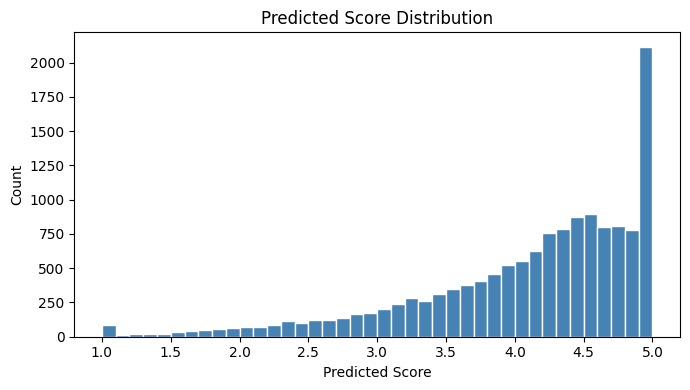

Validation RMSE (best): 0.7598


In [14]:
plt.figure(figsize=(7, 4))
plt.hist(submission['Score'], bins=40, color='steelblue', edgecolor='white')
plt.xlabel('Predicted Score')
plt.ylabel('Count')
plt.title('Predicted Score Distribution')
plt.tight_layout()
plt.savefig('../assets/predicted_score_dist.png', dpi=100)
plt.show()
print('Validation RMSE (best):', round(best_rmse, 4))